In [ ]:
# import packages

# Data Wrangling
import numpy as np
import pandas as pd
import os

# Bayesian Methods
import pymc as pm
import arviz as az

# visualization
import matplotlib.pyplot as plt
az.style.use("arviz-darkgrid")

# update working directory
os.chdir("..")

# import data
dt = pd.read_parquet("data/processed/applications_clean.parquet")

# Creating our Discrete Choice Dataset

In [2]:
# some quick data cleaning

# if 'disabled'/'yes' -> 1; 0 otherwise.
dt['Disability'] = dt['Disability'].isin(["Disabled", "Yes"]).astype(int)

# if NA -> 0
dt['Dependents'] = dt['Dependents'].fillna(0)

# if HH Income missing, drop
dt = dt.dropna(subset = ['HH Income'])

# if HH Assets missing, drop ???
# dt = dt.dropna(subset = ['HH Assets'])

# Impute Age conditional on Income and number of Dependents
def impute_age(df):

    dt['IncomeBin'] = pd.qcut(
        dt['HH Income'],
        q = [0, 0.2, 0.4, 0.6, 0.8, 1],
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
)
    
    # compute group medians
    group_medians = (
        df.groupby(['IncomeBin', 'Dependents'])['Age']
        .median()
        .rename('Age_median')
    )
    
    # merge medians back to df
    df = df.merge(group_medians, on=['IncomeBin', 'Dependents'], how='left')
    
    # impute
    df['Age'] = df['Age'].fillna(df['Age_median'])
    
    # drop helper column
    return df.drop(columns=['Age_median'])

dt = impute_age(dt)


def collapse_race(raw):
    """
    Per current OMB rules.
    """

    r = raw.lower()

    # Hispanic supersedes
    if "hispanic" in r:
        return "Hispanic/Latino"

    # Unknown / prefer not to answer
    if "unknown" in r or "choose" in r or "not" in r:
        return "Unknown"

    # Single-race categories
    if r == "white" or r == "white_mena":
        return "White"
    if "black_african_american" in r and "/" not in r:
        return "Black"
    if r == "asian":
        return "Asian"
    if r == "native_american_alaskan_native":
        return "Native American"

    # Multi-race (non-Hispanic)
    if "/" in r:
        return "Two or More Races"

    # Fallback
    return "Unknown"

dt["race_norm_final"] = dt["race_norm_final"].apply(collapse_race)

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_24056/2291817360.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IncomeBin', 'Dependents'])['Age']


In [3]:
# unique applicants
app_dt = (dt
          .groupby("ID Number")[['Age', 'Disability', 
                                 'HH Size', 'Dependents', 
                                 'race_norm_final', 
                                 'HH Income', 'HH Assets', 
                                 'applicant_MTSP_Income_Limit']].last()).reset_index()

# unique properties
prop_dt = dt[['Application Property', 'Property Maximum Resale Price']].drop_duplicates().dropna()

# creating cartesian product dataset
choice_dt = pd.merge(app_dt, prop_dt, how='cross')

applied_dt = pd.concat(
    (dt[["ID Number", "Application Property"]], 
     pd.Series( np.ones(len(dt)), name="applied")
     ), axis=1)

choice_dt = choice_dt.merge(applied_dt, on=["ID Number", "Application Property"], how="left")
choice_dt["applied"] = choice_dt["applied"].fillna(0)

choice_dt.describe()

,ID Number,Age,Disability,HH Size,Dependents,HH Income,HH Assets,applicant_MTSP_Income_Limit,Property Maximum Resale Price,applied
count,143521.000000,143521.000000,143521.000000,143521.000000,143521.000000,1.435210e+05,141856.000000,131306.000000,143521.000000,143521.000000
mean,507581.228036,41.166895,0.068115,2.073585,0.548031,1.199521e+05,45814.586330,60314.834433,240695.003435,0.012054
std,289801.976351,13.719730,0.251945,1.529239,0.861124,1.950004e+06,59974.096718,12270.922853,45847.938170,0.109127
min,101.000000,0.000000,0.000000,0.000000,0.000000,7.000000e+01,0.000000,40050.000000,148438.000000,0.000000
25%,247829.000000,31.000000,0.000000,1.000000,0.000000,5.200000e+04,14000.000000,52550.000000,204948.000000,0.000000
50%,521641.000000,38.000000,0.000000,2.000000,0.000000,6.400000e+04,30910.000000,57900.000000,235975.000000,0.000000
75%,753912.000000,50.000000,0.000000,3.000000,1.000000,7.700000e+04,60000.000000,66200.000000,273400.000000,0.000000
max,998585.000000,86.000000,1.000000,31.000000,7.000000,7.020040e+07,863967.300000,160900.000000,374062.000000,1.000000


# Model 1 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Priors: } \beta \sim \mathcal{N}(0,1) $$
$$ \text{Interaction Effects Priors: } \beta_{\text{int}} \sim \mathcal{N}(0,0.5) $$
$$ \text{Applicant Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(0,1) $$
$$ \text{Applicant Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(2) $$

---
**Applicant-Level Random Effects**

$$ \gamma_i \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma_i + \mathbf{X_{ij}^T}\beta + \beta_{\text{int}}\mathbf{X_{\text{int}, i,j}} $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

In [ ]:
X_FE = choice_dt[['Age', 'Disability', 'Race', 'HH Size', 'Dependents', 'HH Income', 'Property Maximum Resale Price']]
X_int = choice_dt['HH Income'] * choice_dt['Property Maximum Resale Price']
y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
N_int = 1 #len(X_int.columns)
N_obs = len(X_FE)
app_idx = choice_dt['ID Number']

# transform dataframes to arrays
X_FE_arr = X_FE.values

# scale numeric columns
X_FE_arr[:,[0,3,4,5]]  = (X_FE_arr[:,[0,3,4,5]]  - X_FE_arr[:,[0,3,4,5]].mean(0))  / X_FE_arr[:,[0,3,4,5]].std(0)
X_int_arr = (X_int.values - X_int.values.mean(0)) / X_int.values.std(0)
X_int_arr = X_int_arr.reshape((-1,1))
y_arr = y_applied.values


with pm.Model() as model:

    # hyperpriors
    beta_fe = pm.Normal("beta_fe", mu=0, sigma=1, shape=N_FE)
    beta_int = pm.Normal("beta_int", mu=0, sigma=0.5, shape=N_int)
    mu_app = pm.Normal("mu_app", mu=0, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=2)

    # Applicant-level RE
    gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)

    # Utility calculations
    gamma_for_obs = gamma_i[app_idx].reshape((-1,1))

    fixed_effects_term = X_FE_arr @ beta_fe.reshape((-1,1))
    interaction_term   = X_int_arr @ beta_int.reshape((-1,1))
    eta = gamma_for_obs + fixed_effects_term + interaction_term

    eta = eta.flatten() 
    
    p = pm.invlogit(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_arr)

    idata = pm.sample(draws=200, chains=2, random_seed=42)


Initializing NUTS using advi+adapt_diag...


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Convergence achieved at 178400
Interrupted at 178,399 [89%]: Average Loss = 11,044
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_fe, beta_int, mu_app, sigma_app, gamma_i]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 200 draw iterations (2_000 + 400 draws total) took 444 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
# Generating sampled dataset
sampled_dt = idata.posterior.to_dataframe().reset_index()

In [ ]:
def reformat_sample_dt(sampled_dt):

    # creating wide-format posterior samples df

    # pivot beta_fe
    beta_fe_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="beta_fe_dim_0",
            values="beta_fe"
        )
    )

    # rename columns
    beta_fe_wide.columns = [f"beta_fe[{i}]" for i in beta_fe_wide.columns]

    # pivot gamma_i
    gamma_i_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="gamma_i_dim_0",
            values="gamma_i"
        )
    )

    gamma_i_wide.columns = [f"gamma_i[{i}]" for i in gamma_i_wide.columns]

    # pivot beta_int
    beta_int_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="beta_int_dim_0",
            values="beta_int"
        )
    )

    beta_int_wide.columns = [f"beta_int[{i}]" for i in beta_int_wide.columns]

    # scalar params
    scalars = sampled_dt.drop_duplicates(subset=["chain","draw"])[["chain","draw","mu_app","sigma_app"]]
    scalars = scalars.set_index(["chain","draw"])

    # merge expanded data
    posterior_wide = (
        scalars
        .join(beta_fe_wide)
        .join(beta_int_wide)
        .join(gamma_i_wide)
    )

    return posterior_wide.sort_index().reset_index()

In [ ]:
posterior_wide = reformat_sample_dt(sampled_dt)

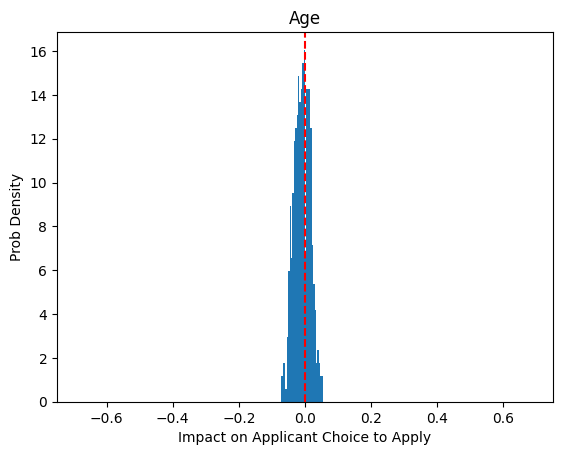

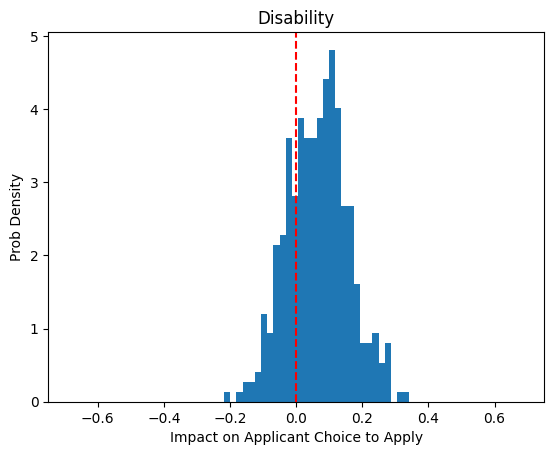

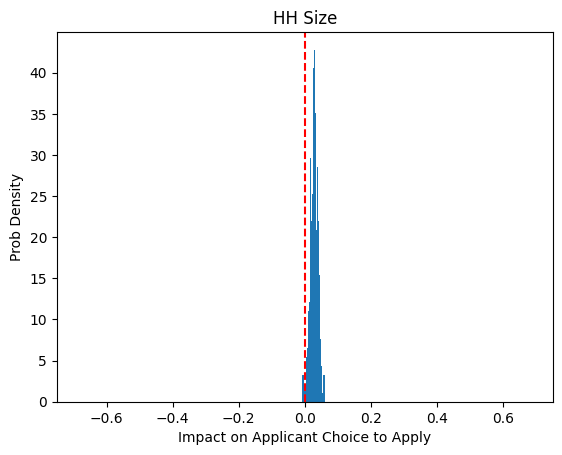

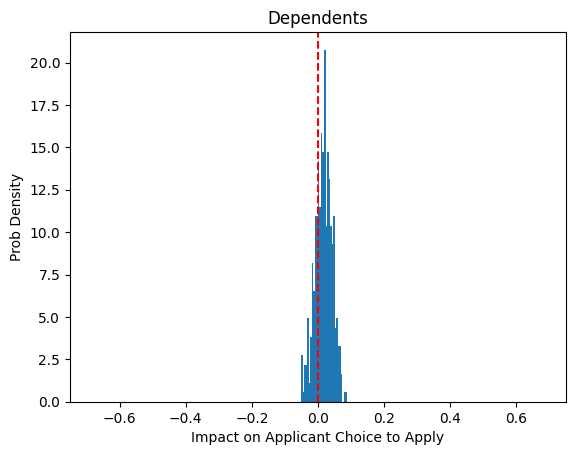

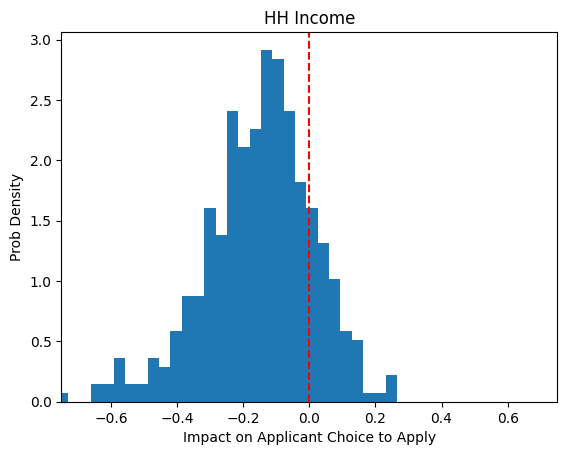

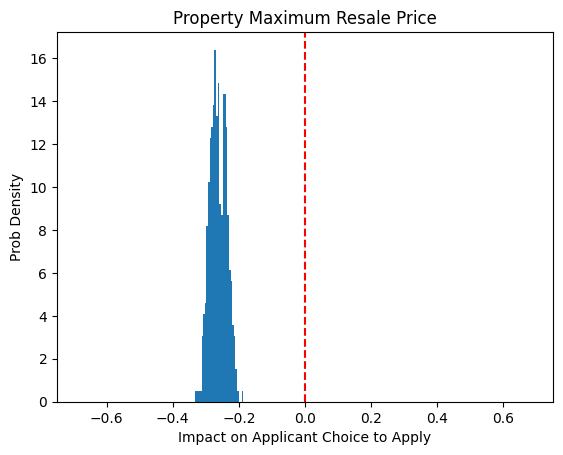

In [83]:
for fe in range(len(X_FE.columns)):

    plt.hist(posterior_wide[f"beta_fe[{fe}]"], density=True, bins=30)
    plt.axvline(x=0, color='red', linestyle='dashed')
    plt.xlim(-0.75,0.75)
    plt.title(X_FE.columns[fe])
    plt.ylabel("Prob Density")
    plt.xlabel("Impact on Applicant Choice to Apply")
    plt.show()


# Model 2 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Mean Hyper-prior: } \mu_\beta \sim \mathcal{N}(0,1) $$
$$ \text{Fixed Effects Variance Hyper-prior: } \sigma_\beta \sim \text{Exp}(1) $$

$$ \text{Fixed Effects Priors: } \beta_\text{race} \sim \mathcal{N}(\mu_\beta, \sigma_\beta) $$
$$ \text{Applicant Random Effect Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(0,1) $$
$$ \text{Applicant Random Effect Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(1) $$

---
**Applicant-Level Random Effects**

$$ \gamma_i \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma_i + \mathbf{X_{ij}^T}\beta_\text{race} $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

In [ ]:
X_FE = choice_dt[['Age', 'Disability', 'HH Size', 'Dependents', 'HH Income', 'Property Maximum Resale Price']]
y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
race_idx = choice_dt["race_norm_final"].astype("category").cat.codes.values
N_race = choice_dt["race_norm_final"].nunique()
N_obs = len(X_FE)
app_idx = choice_dt['ID Number']

# transform dataframes to arrays
X_FE_arr = X_FE.values

# scale numeric columns
X_FE_arr[:,[0,3,4,5]]  = (X_FE_arr[:,[0,3,4,5]]  - X_FE_arr[:,[0,3,4,5]].mean(0))  / X_FE_arr[:,[0,3,4,5]].std(0)
y_arr = y_applied.values


with pm.Model() as model:

    X_data = pm.Data("X_data", X_FE_arr)
    race_idx_data = pm.Data("race_idx", race_idx)
    app_idx_data = pm.Data("app_idx", app_idx)
    y_data = pm.Data("y_data", y_arr)

    # hyperpriors
    mu_beta = pm.Normal("mu_beta", 0, 1, shape=N_FE)
    sigma_beta = pm.Exponential("sigma_beta", 1)
    beta_fe = pm.Normal("beta_fe", mu=mu_beta, sigma=sigma_beta, shape=(N_race, N_FE))

    mu_app = pm.Normal("mu_app", mu=0, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=2)

    # Applicant-level RE (too computationally expensive)
    #gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)
    gamma_for_obs = pm.Normal("gamma", mu=mu_app, sigma=sigma_app)

    # Utility calculations
    #gamma_for_obs = gamma_i[app_idx]

    race_betas = beta_fe[race_idx_data]
    fixed_effects_term = pm.math.sum(race_betas * X_data, axis=1)

    eta = gamma_for_obs + fixed_effects_term
    eta = eta.flatten() 
    
    p = pm.math.sigmoid(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_arr)

    idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_beta, sigma_beta, beta_fe, mu_app, sigma_app, gamma]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 60 tune and 100 draw iterations (120 + 200 draws total) took 221 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [28]:
beta_posterior = idata.posterior["beta_fe"].stack(sample=("chain", "draw")).values

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_24056/3982827405.py:15: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.4)


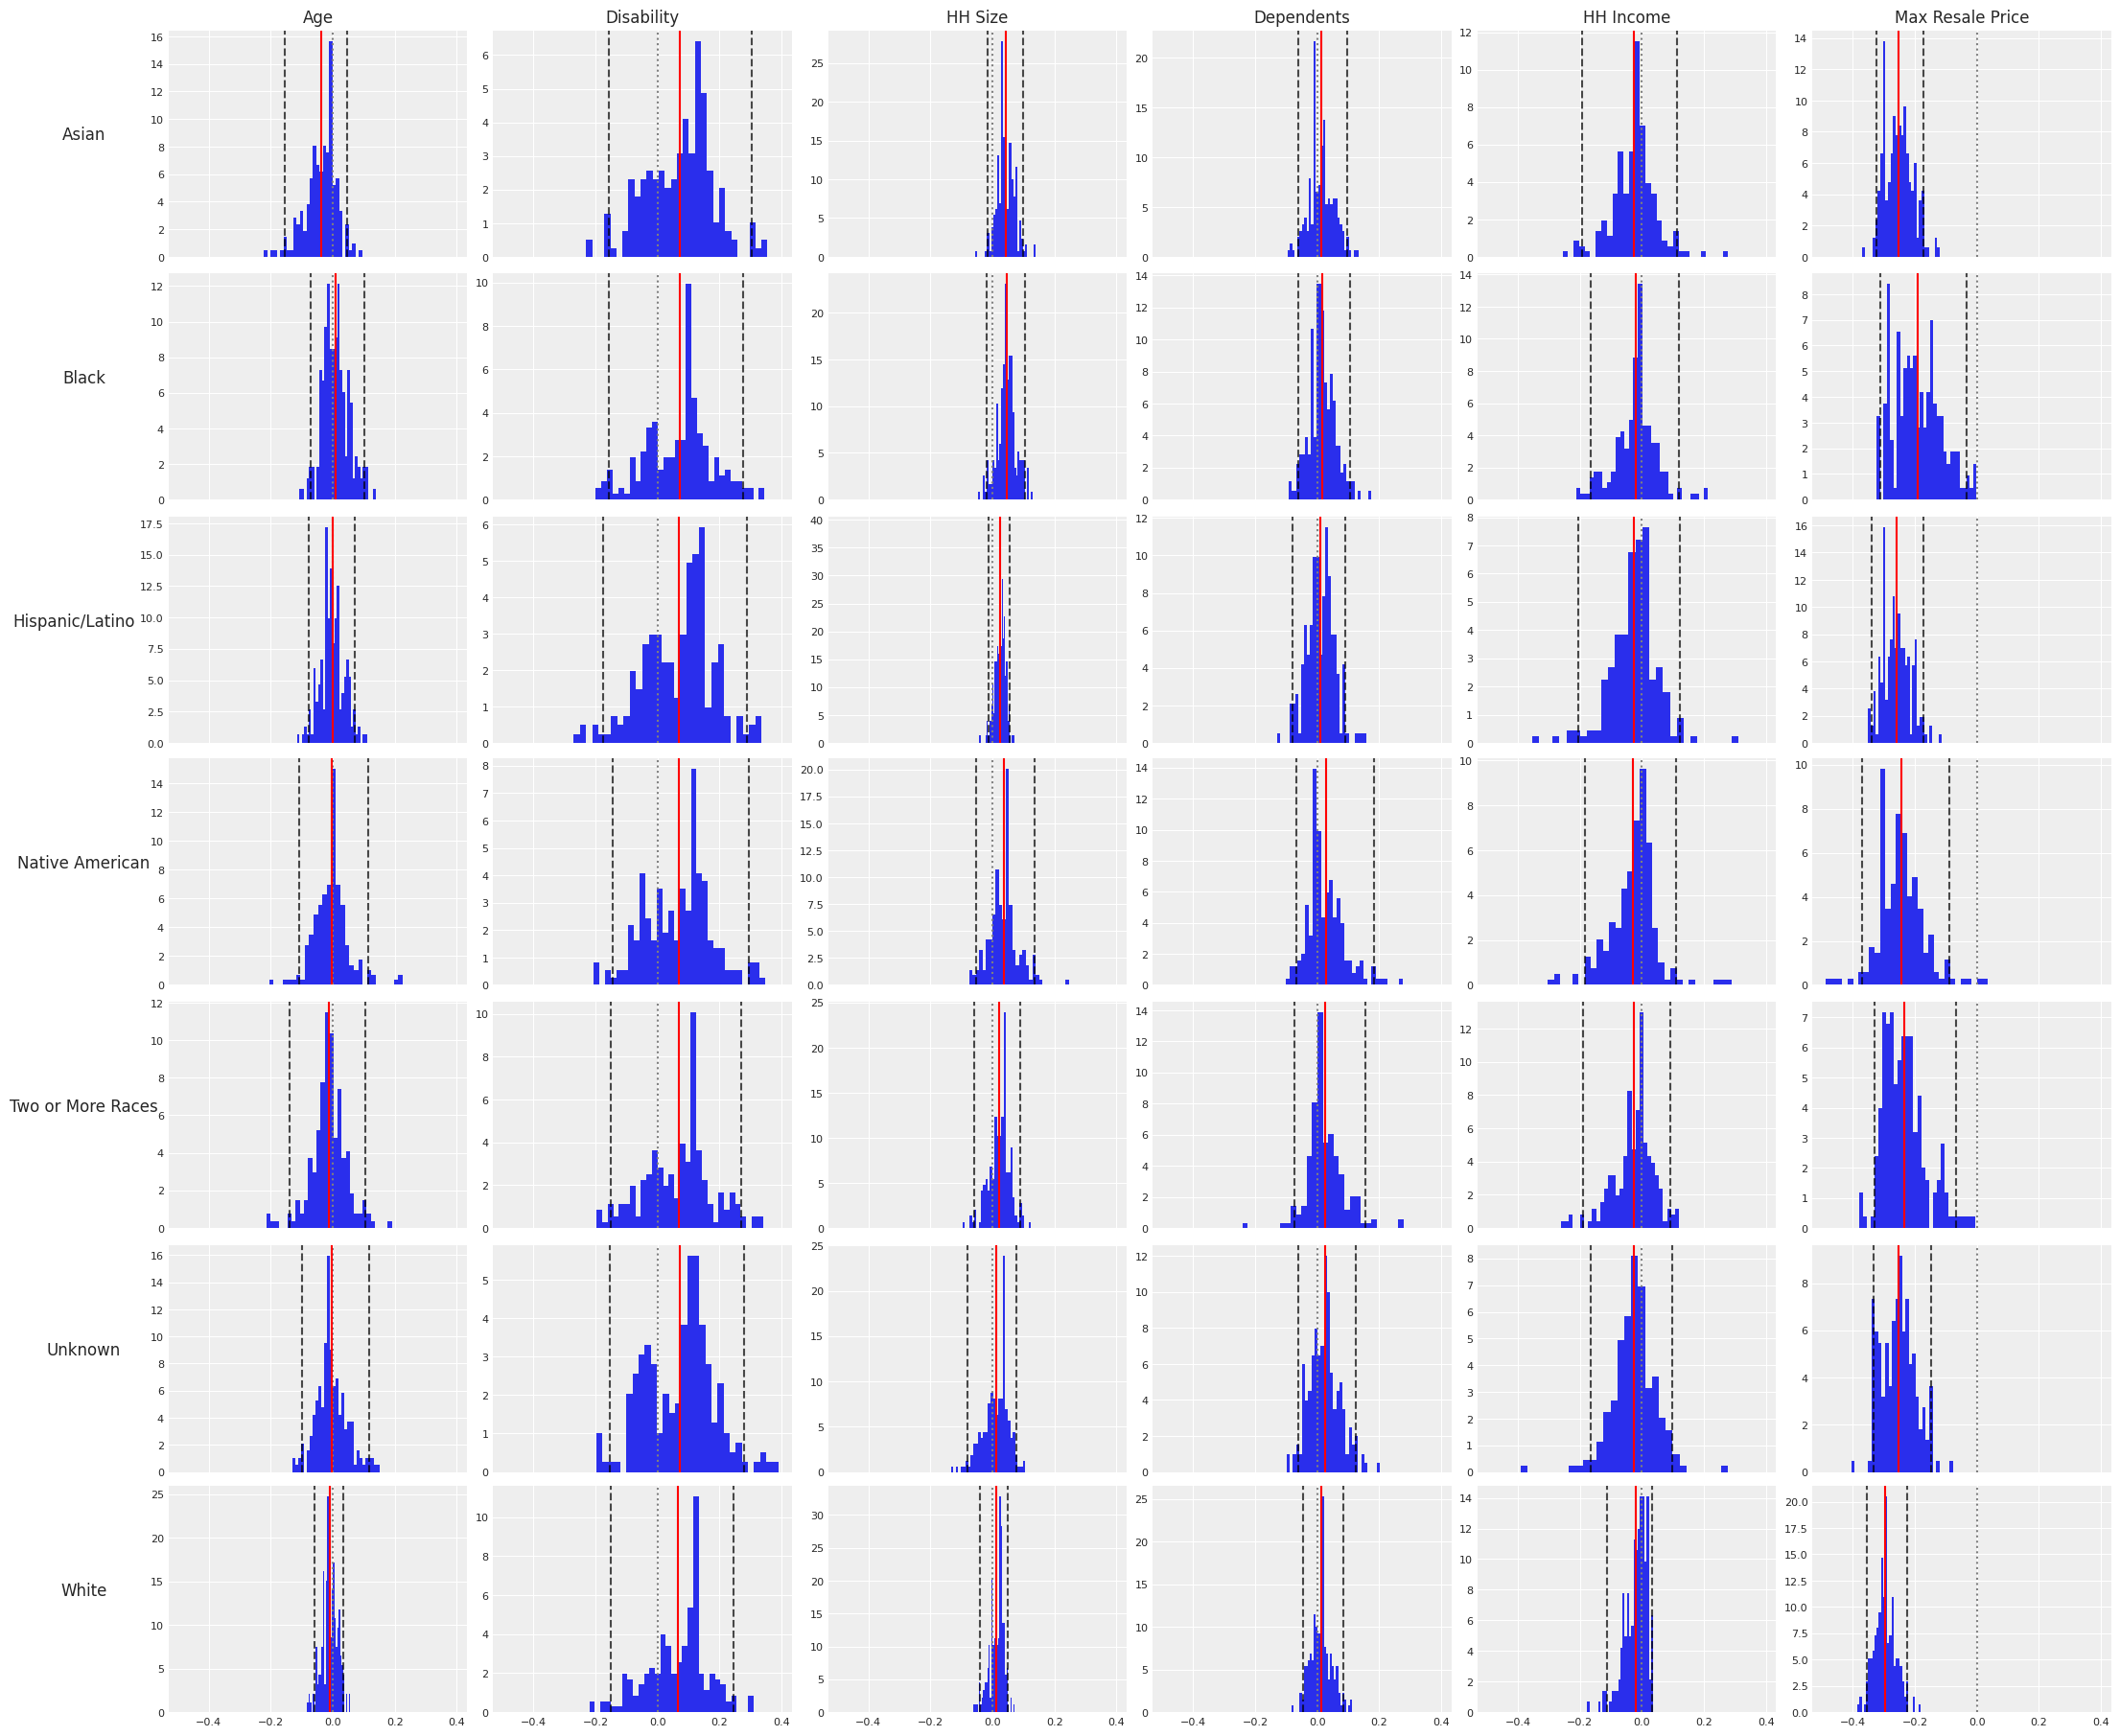

In [ ]:

races = ['Asian', 'Black', 'Hispanic/Latino', 'Native American',
         'Two or More Races', 'Unknown', 'White']

features = ['Age', 'Disability', 'HH Size', 'Dependents',
            'HH Income', 'Max Resale Price']

fig, axs = plt.subplots(
    nrows=len(races), ncols=len(features),
    figsize=(22, 18),
    sharex=True, sharey=False
)

plt.subplots_adjust(hspace=0.6, wspace=0.4)

for r in range(len(races)):
    for c in range(len(features)):
        vals = beta_posterior[r, c, :]

        axs[r, c].hist(vals, density=True, bins=30)

        # mean + credible interval
        mu = vals.mean()
        l, h = np.percentile(vals, [2.5, 97.5])

        axs[r, c].axvline(0, color="gray", linestyle=":")
        axs[r, c].axvline(mu, color="red")
        axs[r, c].axvline(l, color="black", linestyle="--", alpha=0.7)
        axs[r, c].axvline(h, color="black", linestyle="--", alpha=0.7)

        # remove extra ticks
        axs[r, c].tick_params(labelsize=8)

# row/col labels
for r, race in enumerate(races):
    axs[r, 0].set_ylabel(race, fontsize=12, rotation=0, labelpad=50)
for c, feat in enumerate(features):
    axs[0, c].set_title(feat, fontsize=12)

plt.show()


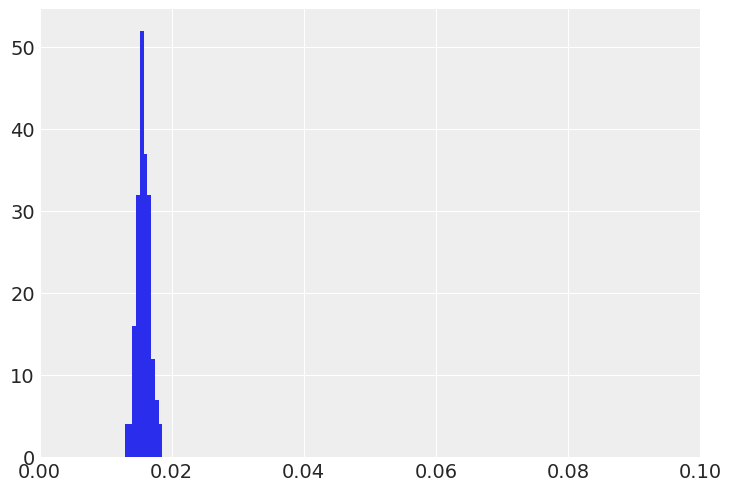

In [49]:
plt.hist(idata.posterior.stack(sample=("chain", "draw")).p.values[0])
plt.xlim(0,.1)
plt.show()